## 08 — T-Cell Subclustering

**Purpose:** Sub-cluster T cells from the merged dataset into 8 subtypes with marker gene characterization.

**Inputs:**
- `_data/obj_merged_71302cells_labeled.rds` — merged Seurat object (from notebook 03)

**Outputs:**
- T-cell subtype UMAP and marker plots

**Run after:** `03_merge_datasets_label_cell_types.ipynb`

# T cell subanalysis

In [1]:
set.seed(1)
source('./utils.R')
obj = readRDS('../_data/obj_merged_71302cells_labeled.rds')

In [2]:
objT = subset(x = obj, subset = cell_type == "T cell")

## Calculate variable genes in each dataset separately

In [3]:
objT_sn = subset(x = objT, subset = dataset == "snRNA-seq") %>% 
            FindVariableFeatures(selection.method = "vst", nfeatures = 500)
objT_sc = subset(x = objT, subset = dataset == "scRNA-seq") %>%
            FindVariableFeatures(selection.method = "vst", nfeatures = 500)

Finding variable features for layer counts

Finding variable features for layer counts



## Normalization and PCA

In [4]:
.verbose = FALSE
objT = objT %>% ScaleData(features = rownames(objT), verbose = .verbose) %>% 
                RunPCA(features = c(VariableFeatures(objT_sn), VariableFeatures(objT_sc)), verbose = .verbose) %>%
                RunUMAP(dims = 1:20, verbose = .verbose)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’



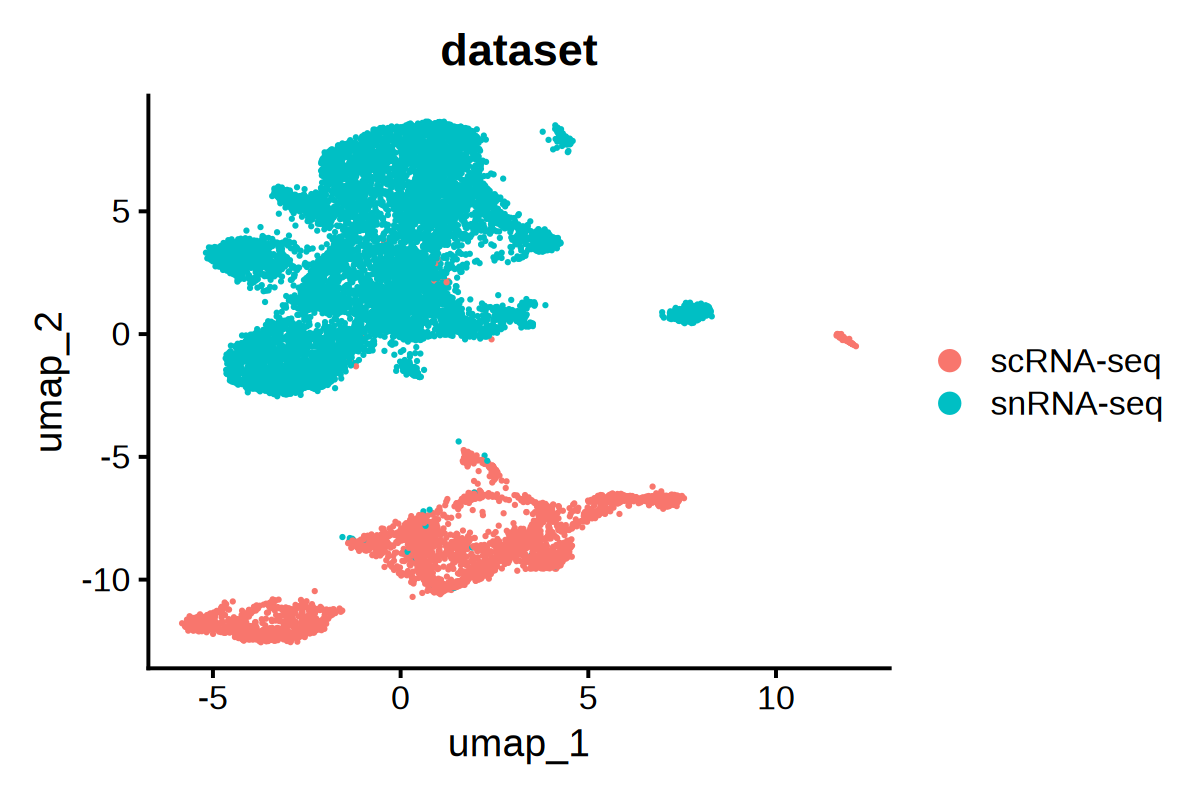

In [5]:
# pre-harmony PCA
fig.size(4, 6)
DimPlot(objT, reduction = "umap", group.by = "dataset", shuffle = TRUE)

## Harmony

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony converged after 2 iterations

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’



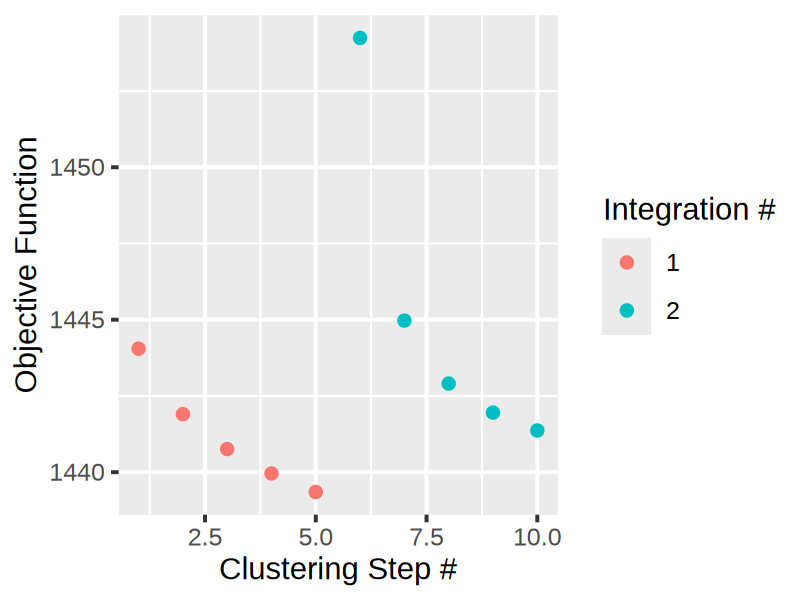

In [6]:
set.seed(1)
fig.size(3, 4)
objT = objT %>% RunHarmony(c("Subject", "dataset", "Run"), theta = c(1, 1, 0.5), plot_convergence = TRUE) %>%
    RunUMAP(reduction = "harmony", dims = 1:20, verbose = .verbose) %>% 
    FindNeighbors(reduction = "harmony", dims = 1:20, verbose = .verbose) %>% 
    FindClusters(resolution = 0.2, verbose = .verbose) %>% 
    identity()

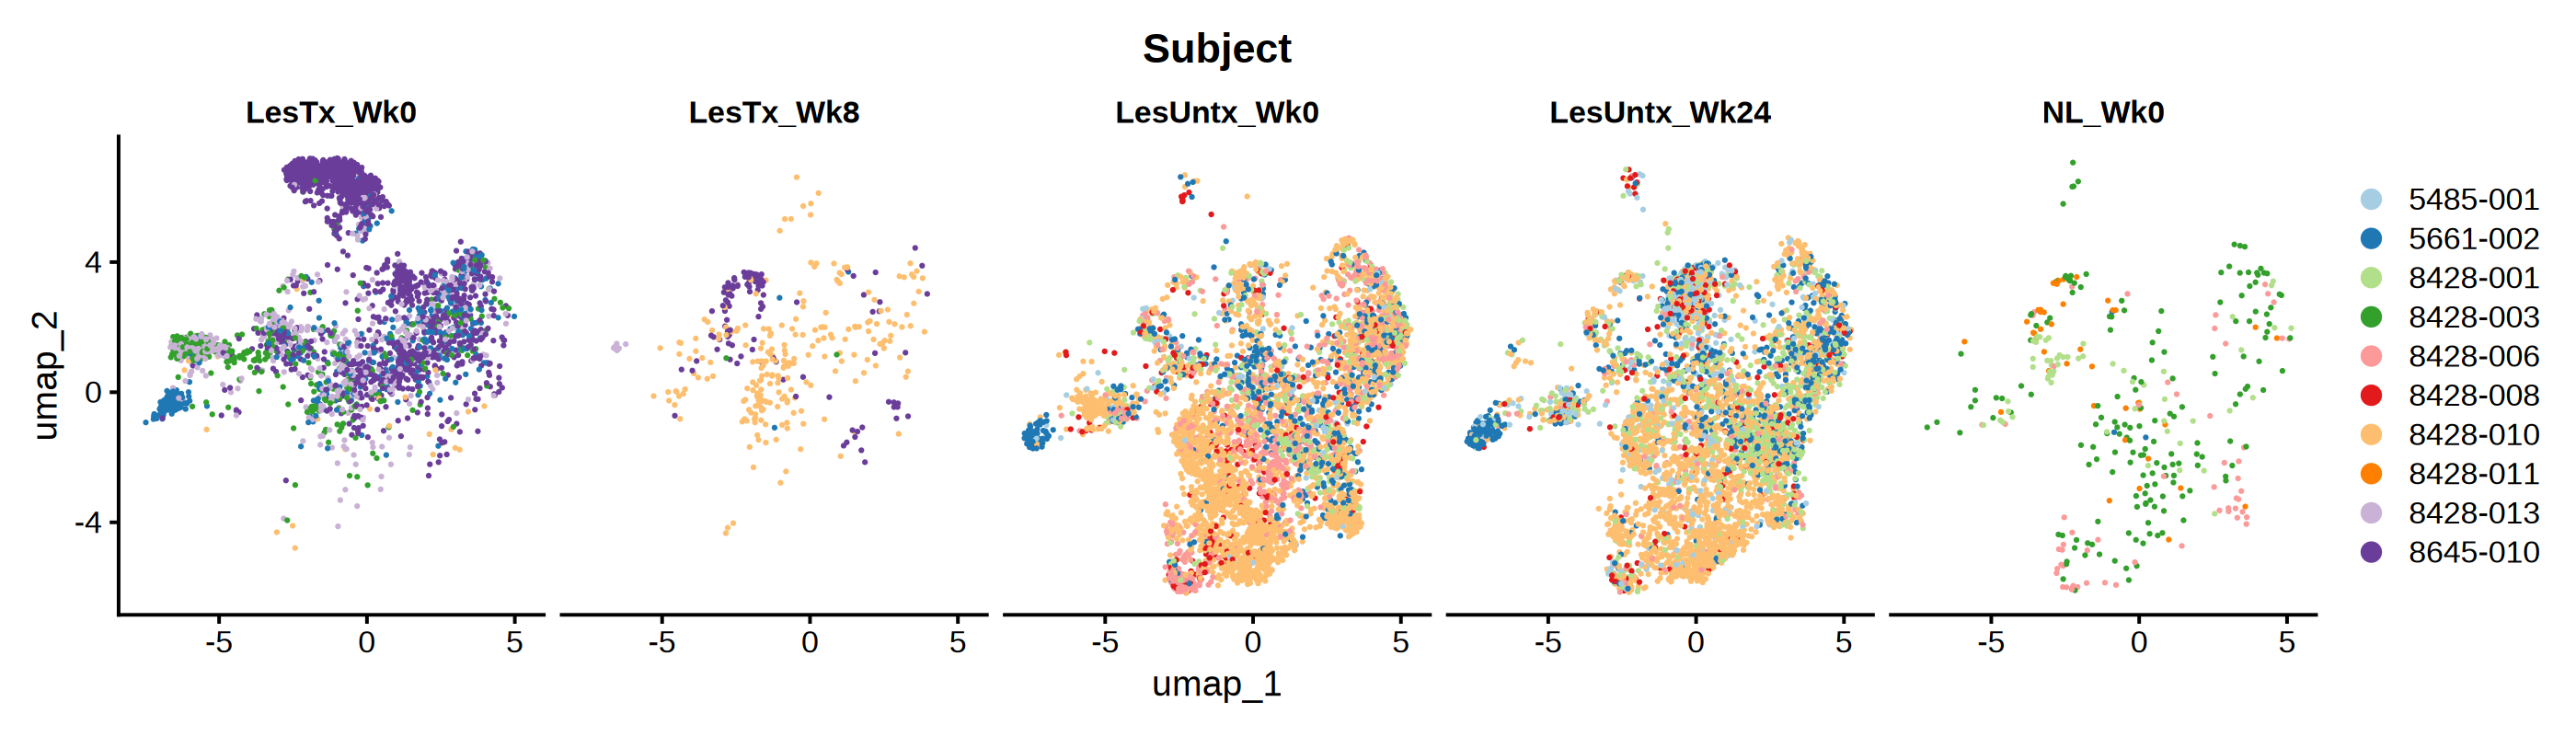

In [23]:
fig.size(4, 14)
DimPlot(objT, reduction = "umap", shuffle = TRUE, group.by = 'Subject', split.by = 'Condition') + 
    scale_color_brewer(palette = 'Paired')

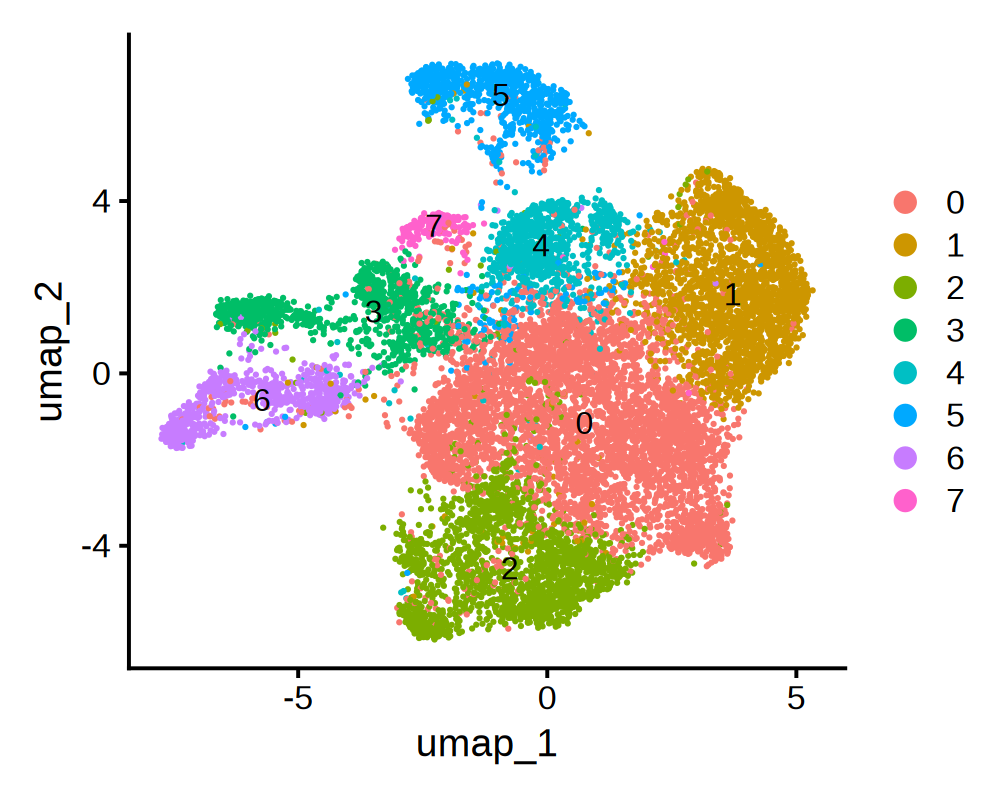

In [8]:
fig.size(4, 5)
DimPlot(objT, reduction = "umap", shuffle = TRUE, label = TRUE)

## Differential expression by cluster - snRNA-seq

In [9]:
objT_sn = subset(objT, subset = dataset == 'snRNA-seq')
objT_sn_presto = wilcoxauc(objT_sn, 'RNA_snn_res.0.2')
head(objT_sn_presto)

,feature,group,avgExpr,logFC,statistic,auc,pval,padj,pct_in,pct_out
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,SAMD11,0,0.0008310362,0.0008310362,11541118,0.5001246,0.231480849,0.46160448,0.02491281,0.00000000
2,NOC2L,0,0.0628224639,-0.0038658211,11507821,0.4986817,0.448790266,0.66862030,2.79023418,3.06140198
3,KLHL17,0,0.0266813510,-0.0025005987,11503366,0.4984886,0.203243806,0.43591429,1.17090184,1.47851800
4,PLEKHN1,0,0.0228776994,-0.0077277041,11484108,0.4976541,0.040050878,0.14067131,0.97159940,1.44372934
5,PERM1,0,0.0012377704,-0.0001120092,11537970,0.4999882,0.959526634,1.00000000,0.04982561,0.05218299
6,HES4,0,0.0151212889,-0.0137019077,11462576,0.4967210,0.001628312,0.01085305,0.64773293,1.30457471


In [10]:
markers = top_markers(objT_sn_presto, n = 5)
markers = markers[, -1]
markers = markers[, as.character(0:(ncol(markers)-1))]
head(markers)

0,1,2,3,4,5,6,7
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
THEMIS,TTN,NAMPT,AOAH,WDFY4,SORCS1,RIN3,IFIT2
INPP4B,LDLRAD4,EML4,SAMD3,LRMDA,KDSR,ATP8B4,IFIT3
ARHGAP15,IKZF2,AHR,PRKCB,CD74,JAK1,NCALD,IFIH1
ANK3,CCDC141,AKAP13,ARHGAP26,TRIO,IMMP2L,SFMBT2,OASL
TC2N,PTPRJ,PDE4D,ITGA4,DST,PACSIN2,CD96,ZC3HAV1


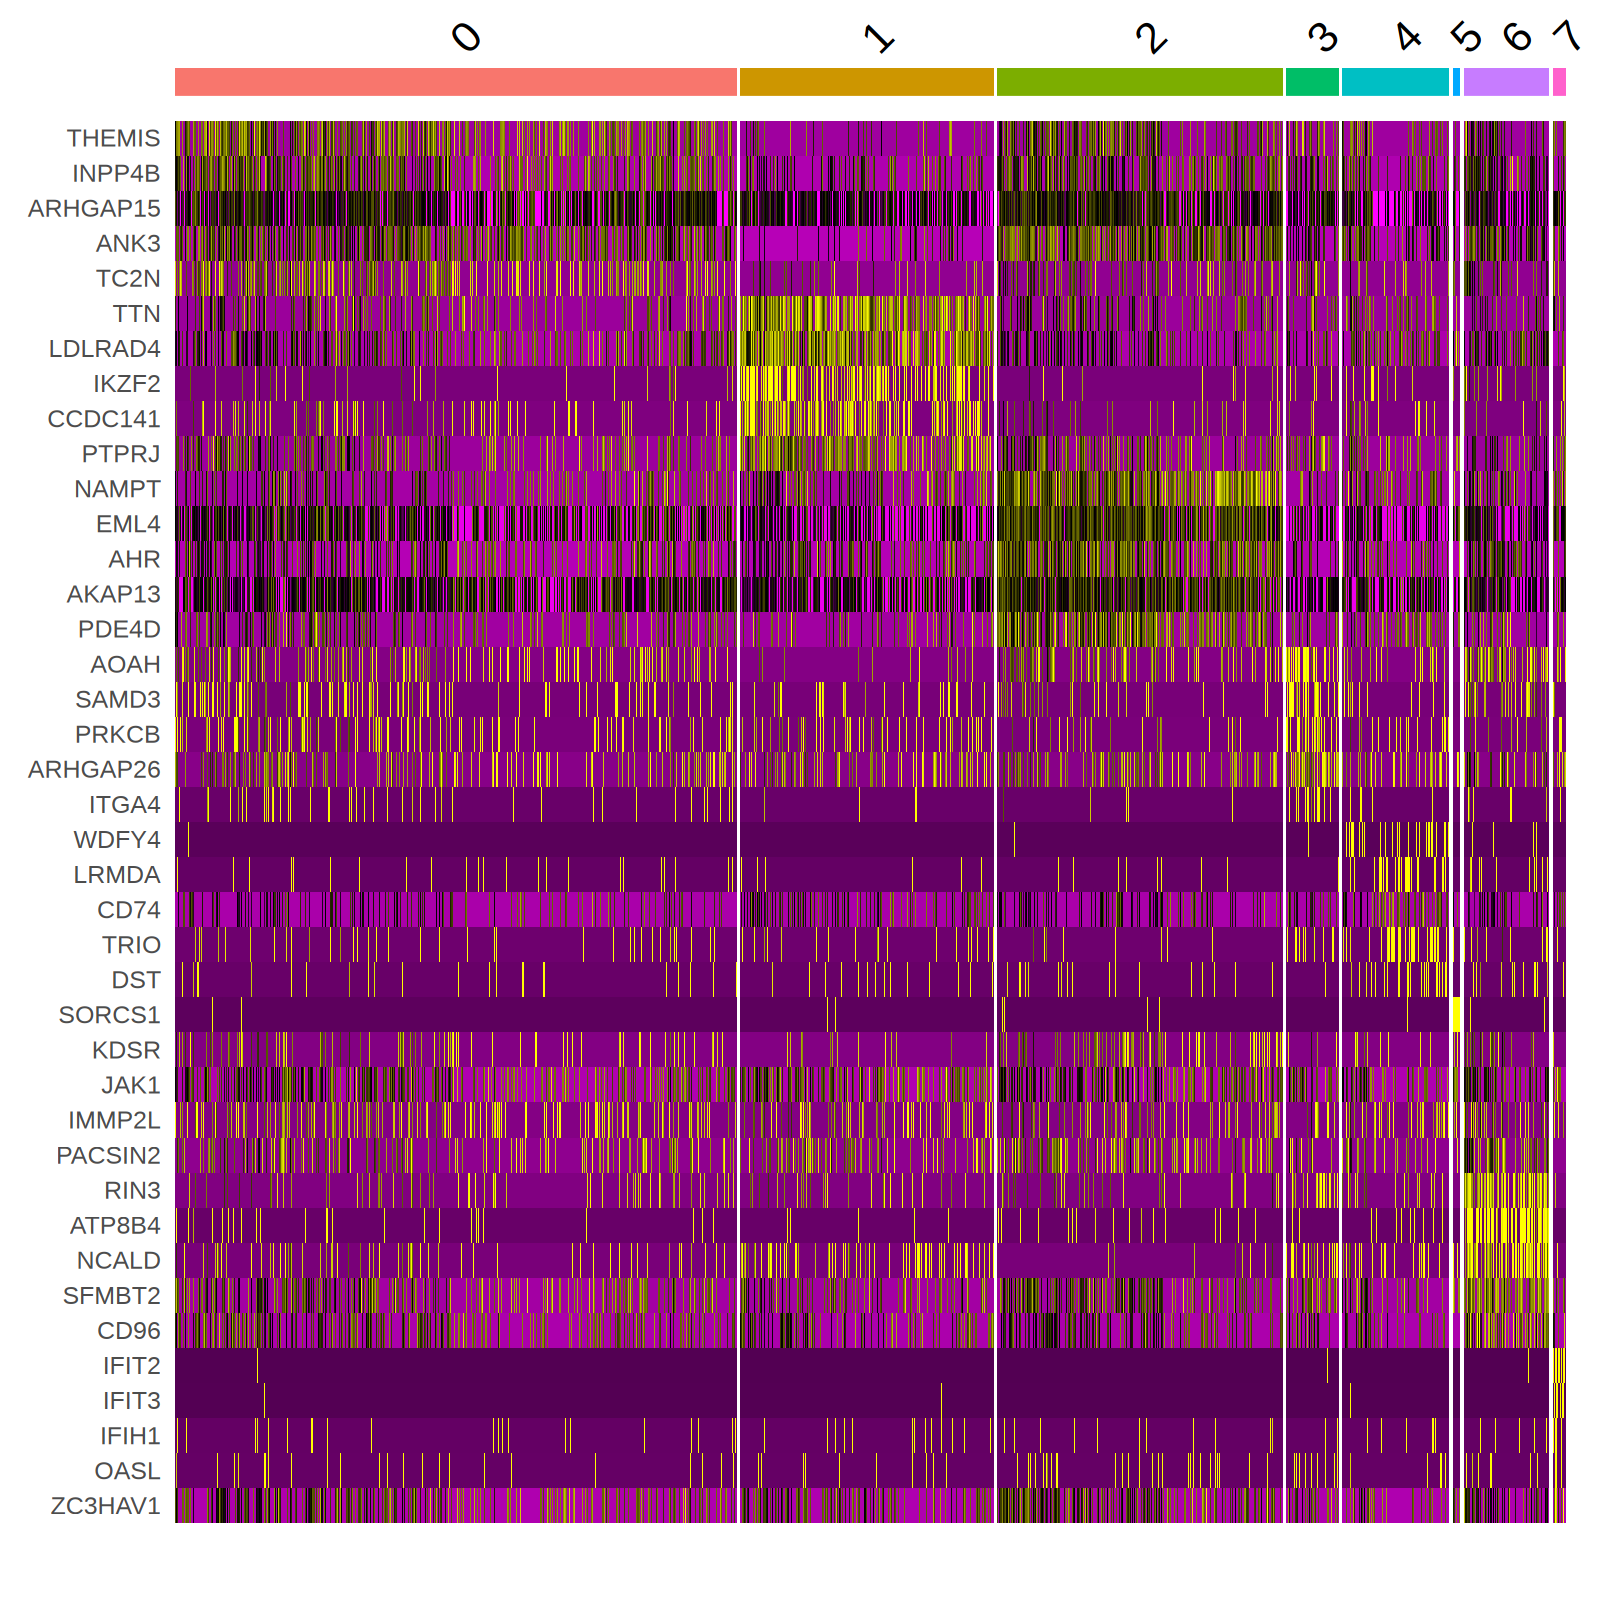

In [11]:
fig.size(8, 8)
DoHeatmap(subset(objT_sn), features = unlist(markers)) + NoLegend()

## Differential expression by cluster - scRNA-seq

In [12]:
objT_sc = subset(objT, subset = dataset == 'scRNA-seq')
objT_sc_presto = wilcoxauc(objT_sn, 'RNA_snn_res.0.2')
head(objT_sc_presto)

,feature,group,avgExpr,logFC,statistic,auc,pval,padj,pct_in,pct_out
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,SAMD11,0,0.0008310362,0.0008310362,11541118,0.5001246,0.231480849,0.46160448,0.02491281,0.00000000
2,NOC2L,0,0.0628224639,-0.0038658211,11507821,0.4986817,0.448790266,0.66862030,2.79023418,3.06140198
3,KLHL17,0,0.0266813510,-0.0025005987,11503366,0.4984886,0.203243806,0.43591429,1.17090184,1.47851800
4,PLEKHN1,0,0.0228776994,-0.0077277041,11484108,0.4976541,0.040050878,0.14067131,0.97159940,1.44372934
5,PERM1,0,0.0012377704,-0.0001120092,11537970,0.4999882,0.959526634,1.00000000,0.04982561,0.05218299
6,HES4,0,0.0151212889,-0.0137019077,11462576,0.4967210,0.001628312,0.01085305,0.64773293,1.30457471


In [13]:
markers = top_markers(objT_sc_presto, n = 5)
markers = markers[, -1]
markers = markers[, as.character(0:(ncol(markers)-1))]
head(markers)

0,1,2,3,4,5,6,7
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
THEMIS,TTN,NAMPT,AOAH,WDFY4,SORCS1,RIN3,IFIT2
INPP4B,LDLRAD4,EML4,SAMD3,LRMDA,KDSR,ATP8B4,IFIT3
ARHGAP15,IKZF2,AHR,PRKCB,CD74,JAK1,NCALD,IFIH1
ANK3,CCDC141,AKAP13,ARHGAP26,TRIO,IMMP2L,SFMBT2,OASL
TC2N,PTPRJ,PDE4D,ITGA4,DST,PACSIN2,CD96,ZC3HAV1


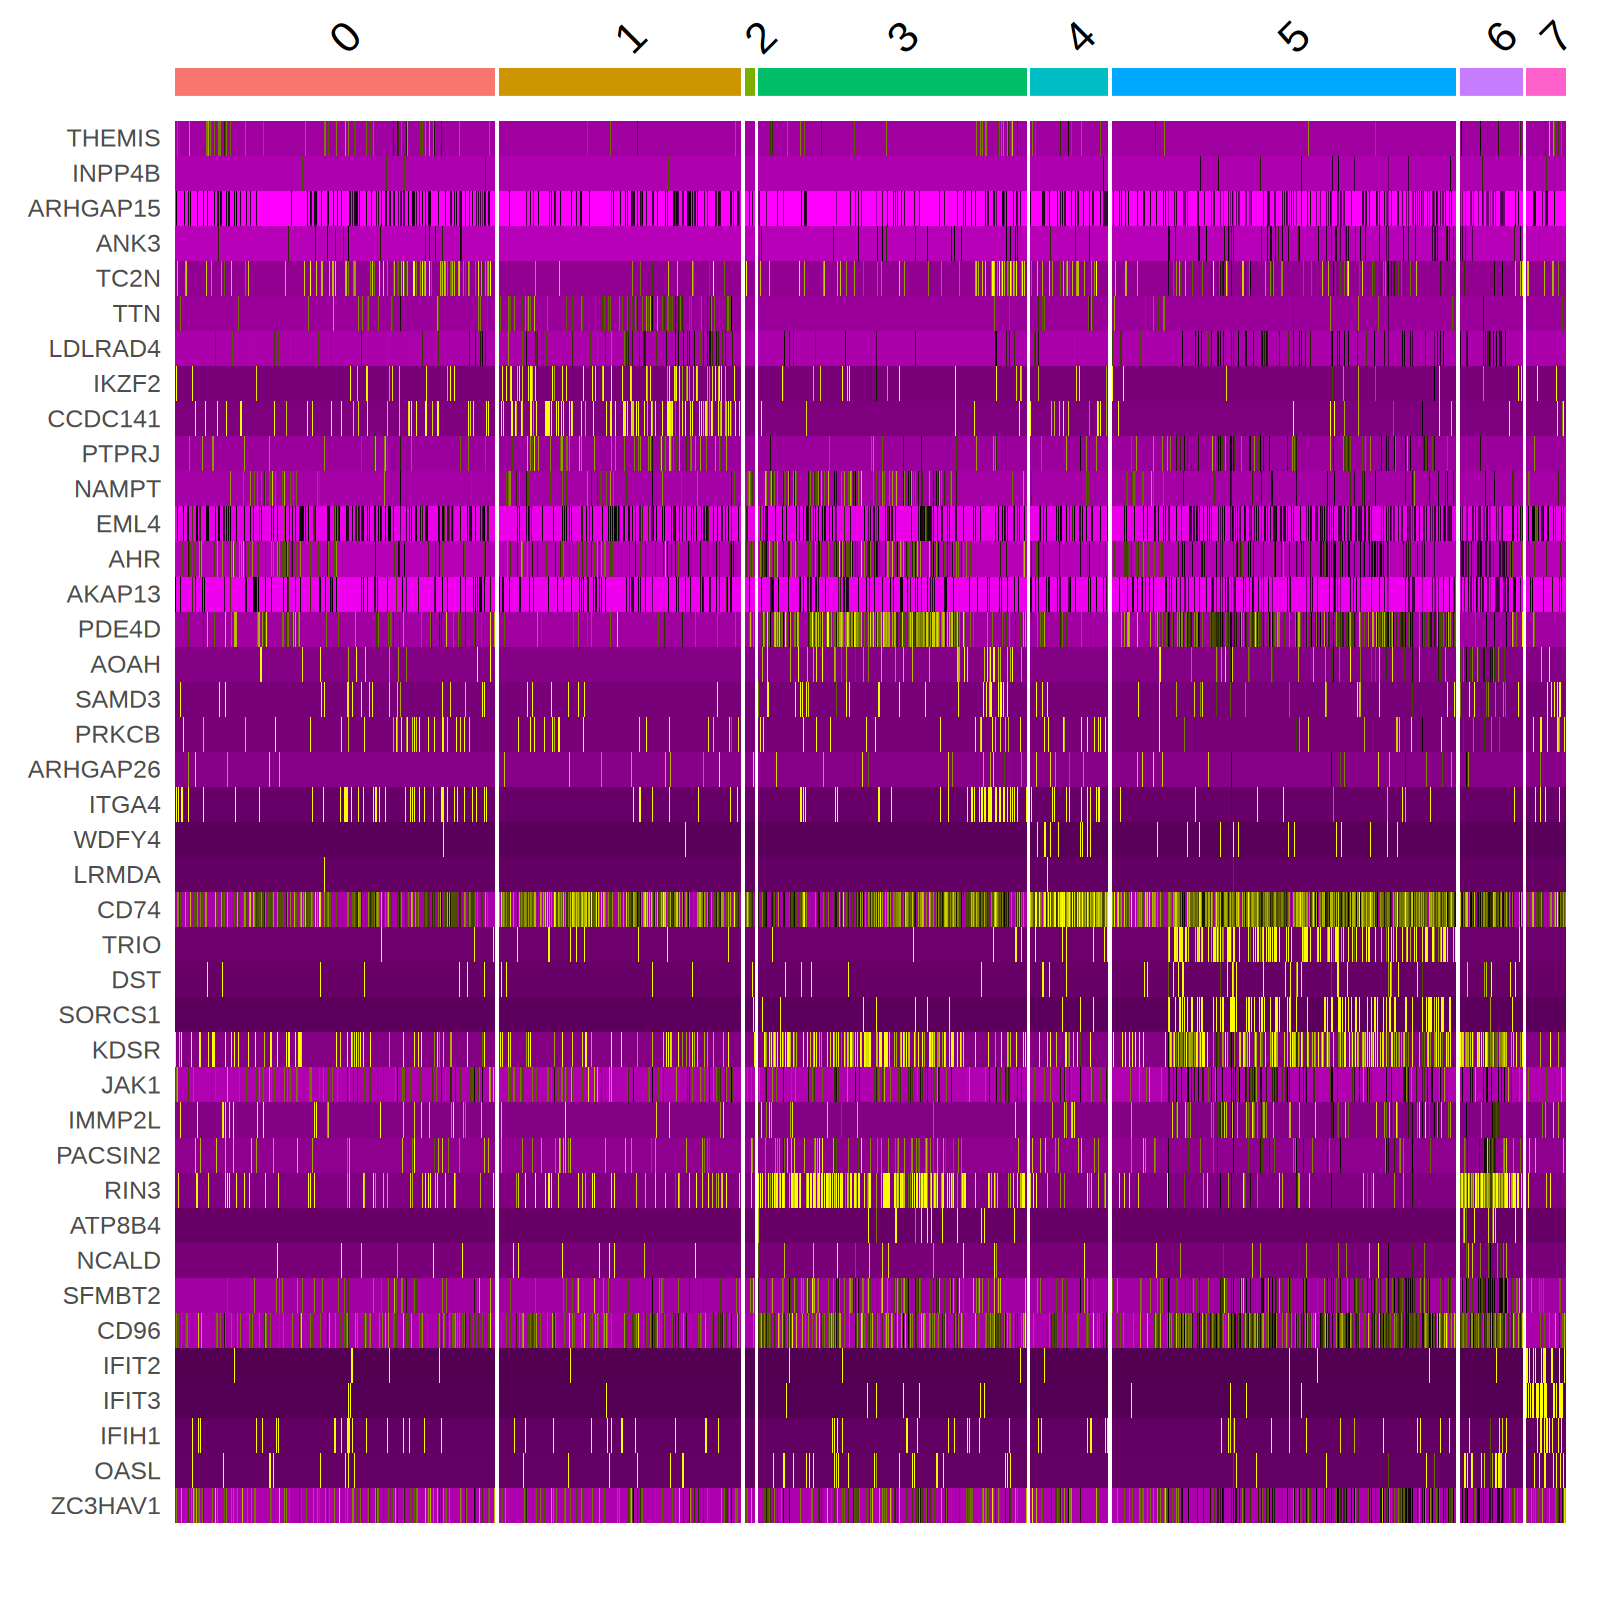

In [14]:
fig.size(8, 8)
DoHeatmap(subset(objT_sc), features = unlist(markers)) + NoLegend()

## Differential expression by cluster - together

In [15]:
obj_presto = wilcoxauc(objT, 'RNA_snn_res.0.2')
head(obj_presto)

,feature,group,avgExpr,logFC,statistic,auc,pval,padj,pct_in,pct_out
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,SAMD11,0,0.0006952437,0.0002544846,19923050,0.4999838,9.062169e-01,9.484364e-01,0.02084202,0.02408188
2,NOC2L,0,0.0689050123,-0.0173244369,19726820,0.4950593,3.265582e-03,9.603800e-03,2.91788245,3.92534618
3,KLHL17,0,0.0302423583,-0.0241252695,19661324,0.4934156,3.881006e-07,2.700239e-06,1.25052105,2.57676099
4,PLEKHN1,0,0.0213153256,-0.0162453878,19752684,0.4957084,7.200156e-05,3.171511e-04,0.89620675,1.75797712
5,PERM1,0,0.0010355170,0.0001011542,19924802,0.5000278,8.753977e-01,9.315195e-01,0.04168404,0.03612282
6,HES4,0,0.0157429549,-0.0131383989,19805478,0.4970332,1.145509e-03,3.785812e-03,0.64610254,1.24021674


In [16]:
markers = top_markers(obj_presto, n = 5)
markers = markers[, -1]
markers = markers[, as.character(0:(ncol(markers)-1))]
head(markers)

0,1,2,3,4,5,6,7
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
THEMIS,TTN,EML4,CCL5,WDFY4,TRBC1,RIN3,IFIT2
ARHGAP15,LDLRAD4,NAMPT,TMSB4X,CD74,LTB,ATP8B4,IFIT3
INPP4B,IKZF2,AKAP13,B2M,LRMDA,S100A9,NCALD,IFI44
ANK3,CCDC141,CCNL1,DUSP2,F13A1,IL32,PIK3AP1,IFI6
TC2N,STAM,SIK3,ZFP36L2,TRIO,MT-ATP6,NTRK2,B2M


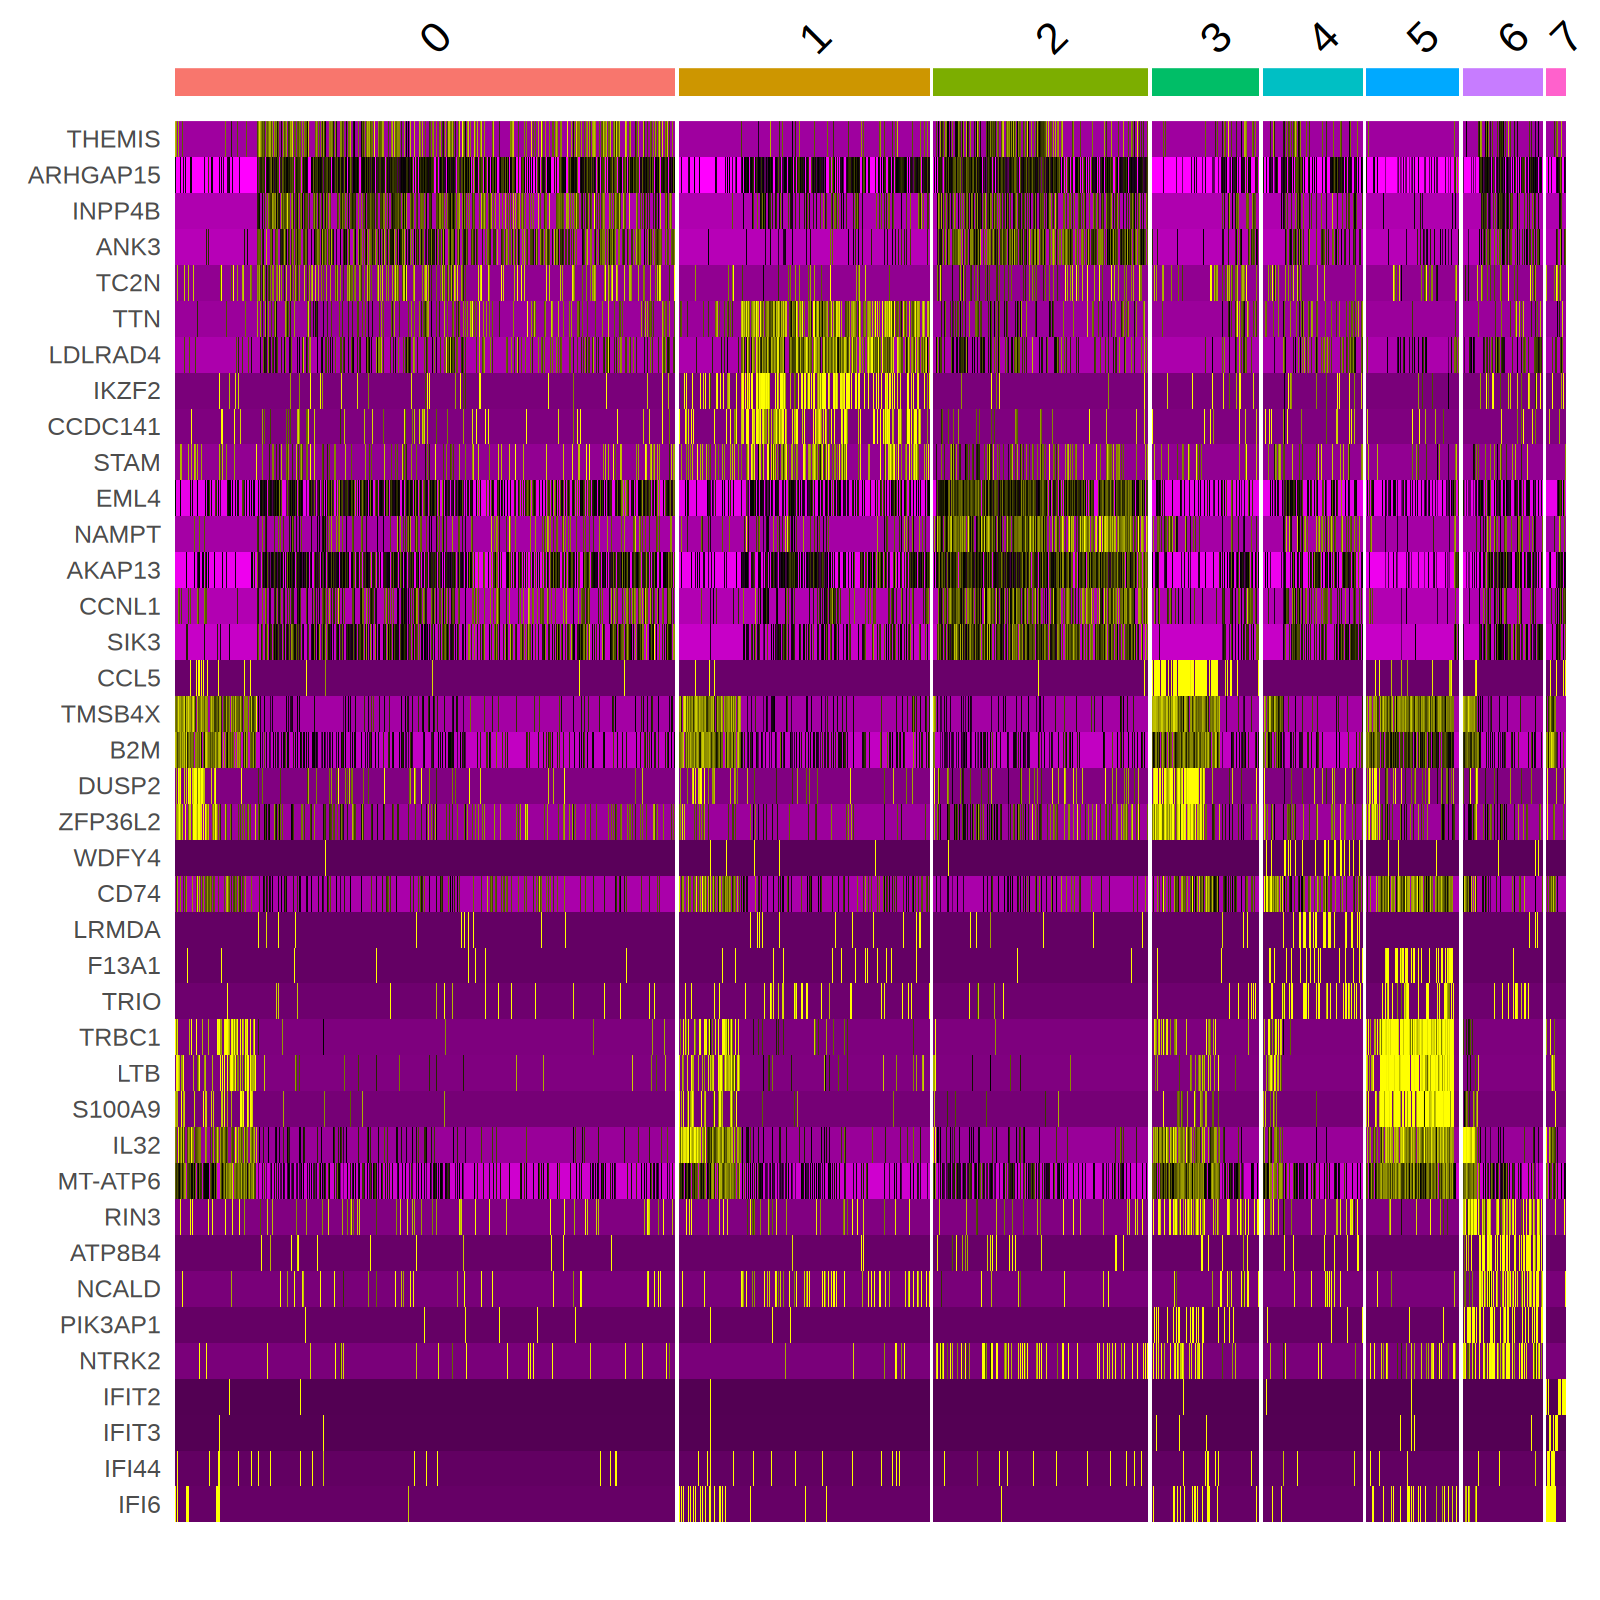

In [17]:
fig.size(8, 8)
DoHeatmap(subset(objT), features = unlist(markers)) + NoLegend()

In [18]:
saveRDS(objT, '../data/obj_merged_T.rds')

## Marker genes

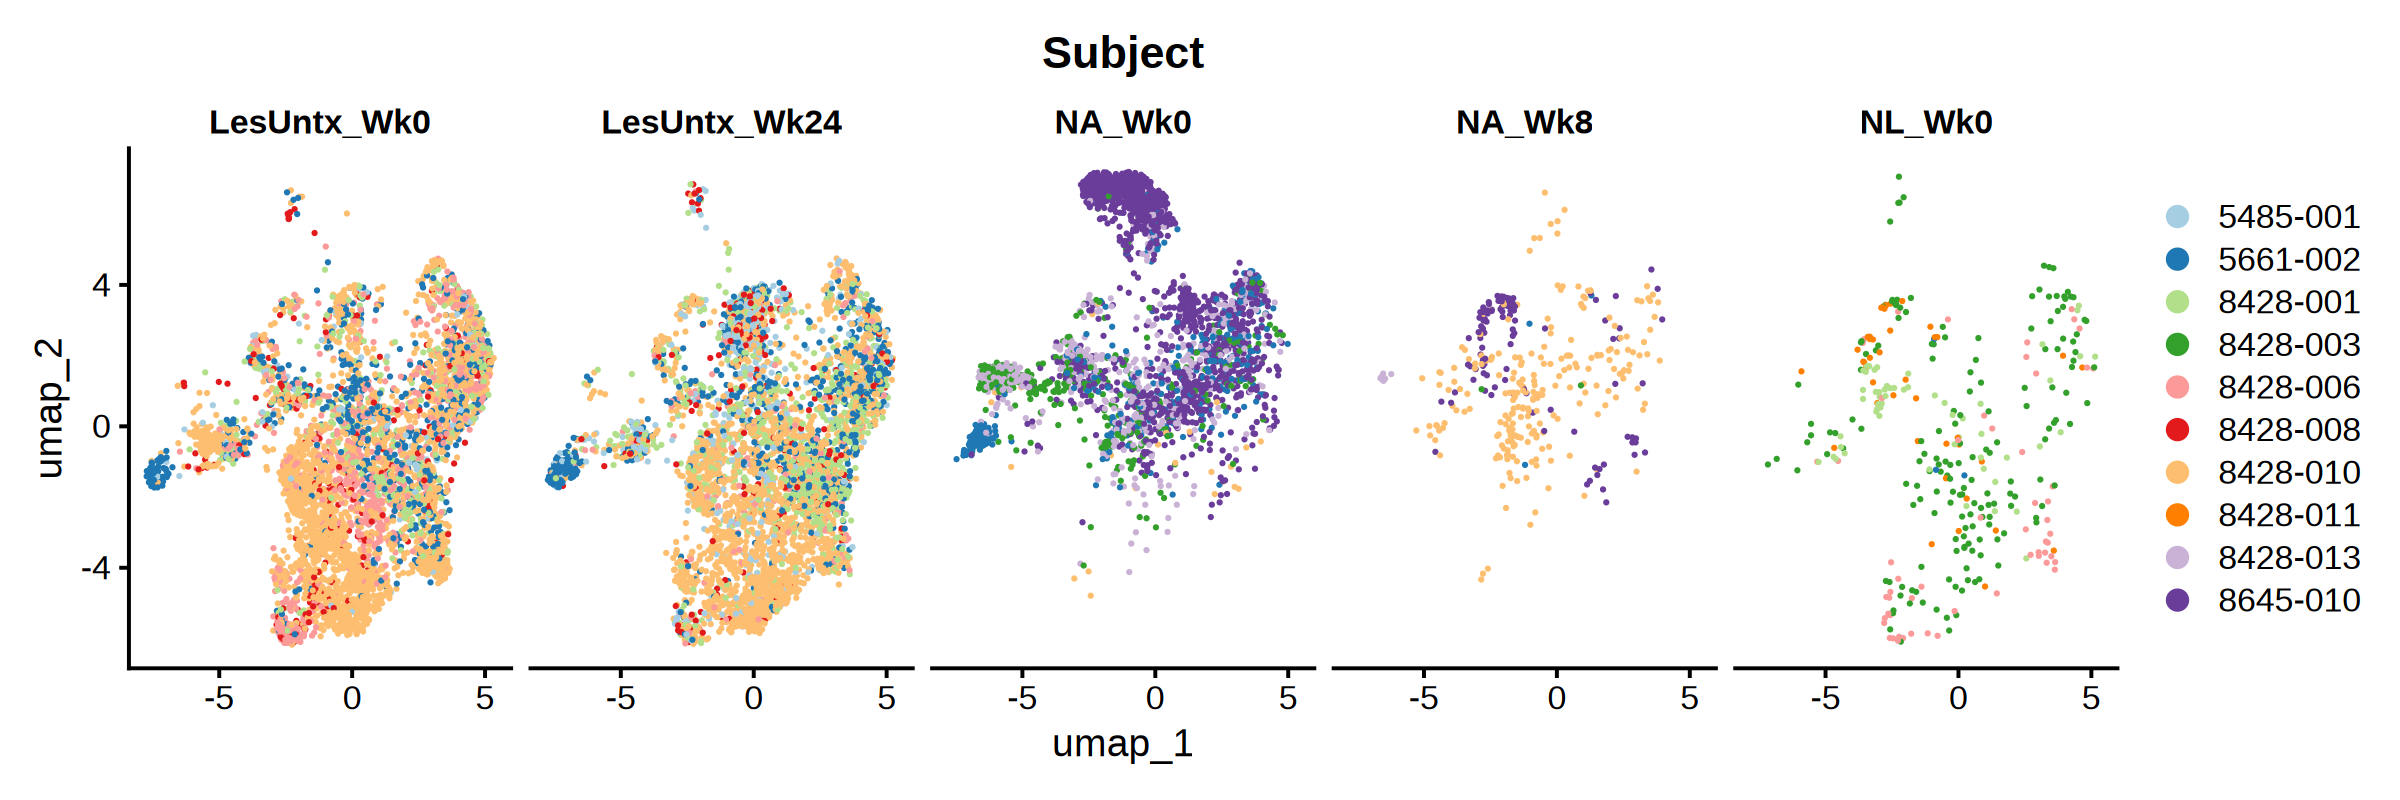

In [19]:
#objT = readRDS('../data/obj_merged_T.rds')
objT@meta.data$Type_TimePt = paste0(objT@meta.data$Type, '_', objT@meta.data$TimePt)
fig.size(4, 12)
DimPlot(objT, reduction = "umap", shuffle = TRUE, group.by = 'Subject', split.by = 'Type_TimePt') + 
    scale_color_brewer(palette = 'Paired')

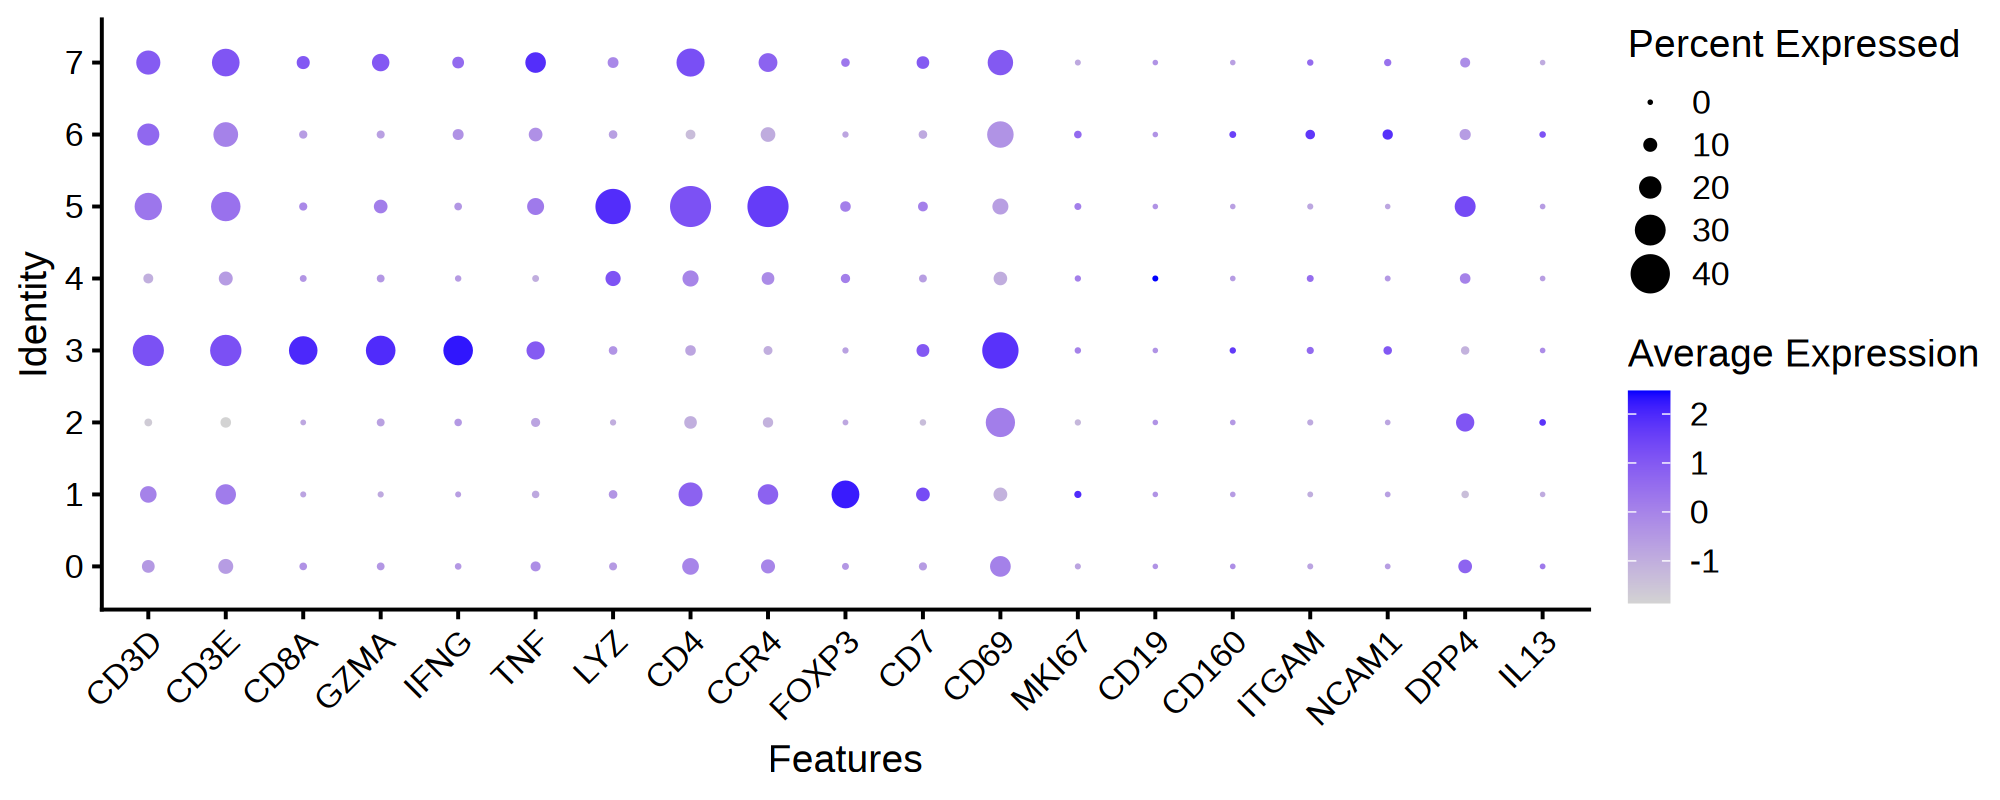

In [40]:
fig.size(4, 10)
DotPlot(objT, features = c('CD3D', 'CD3E', 'CD8A', 'GZMA', 'IFNG', 'TNF', 
                           'LYZ', 'CD4', 'CCR4', 
                           'FOXP3', 'CD7', 'CD69', 'MKI67', 
                           'CD19', 'CD160', 'ITGAM', 'NCAM1',  'DPP4',  'IL13'))  + RotatedAxis()

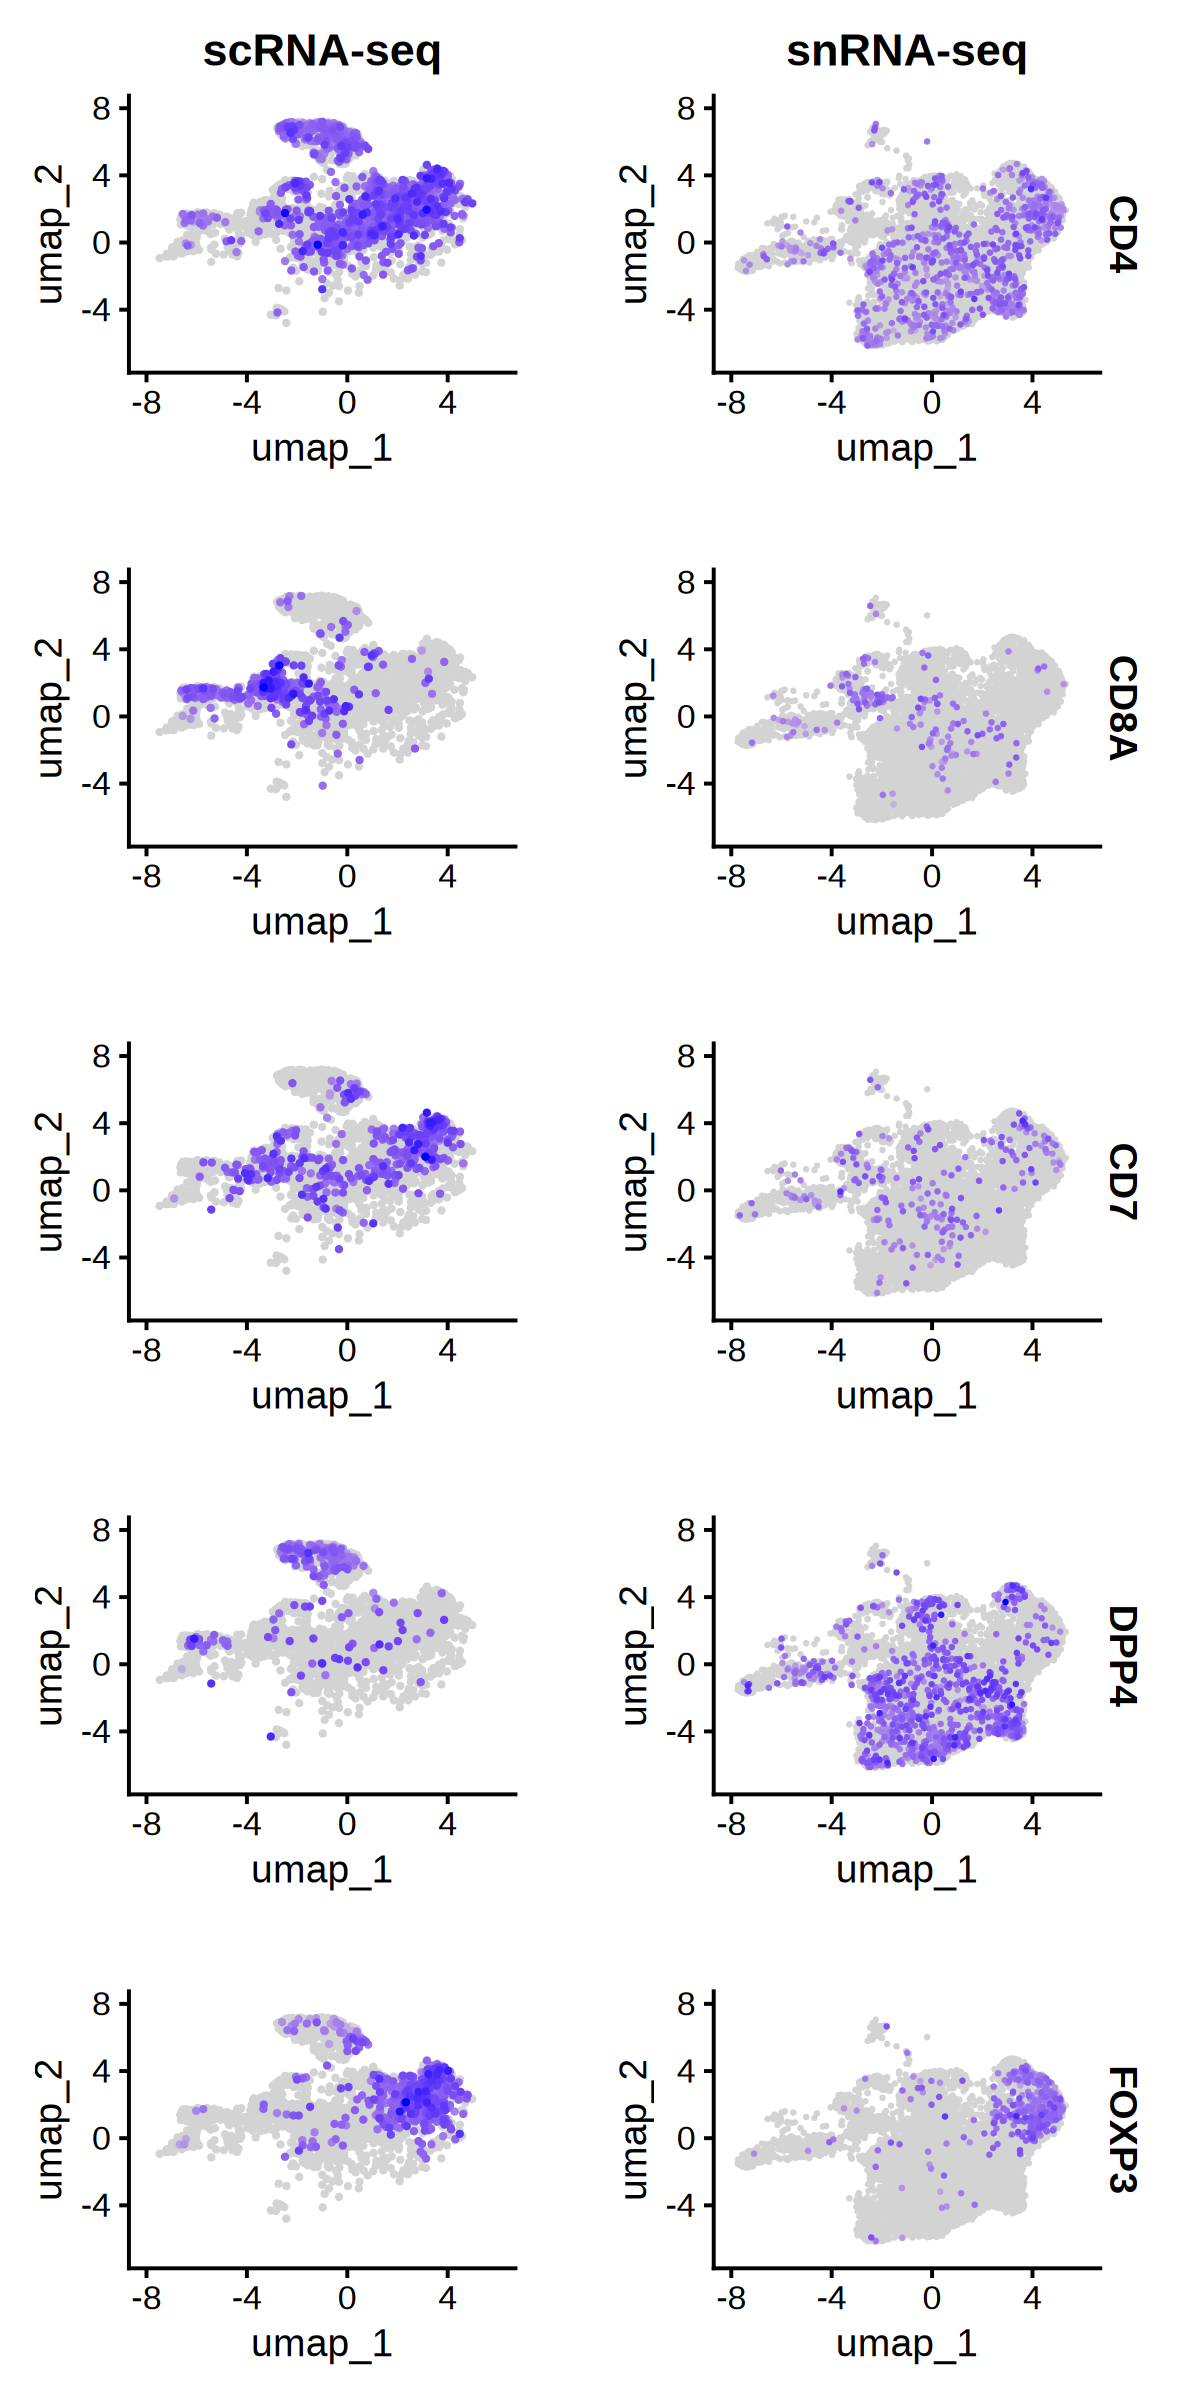

In [21]:
fig.size(12, 6)
FeaturePlot(objT, features = c('CD4', 'CD8A', 'CD7', 'DPP4', 'FOXP3'), order = TRUE, split.by = 'dataset')

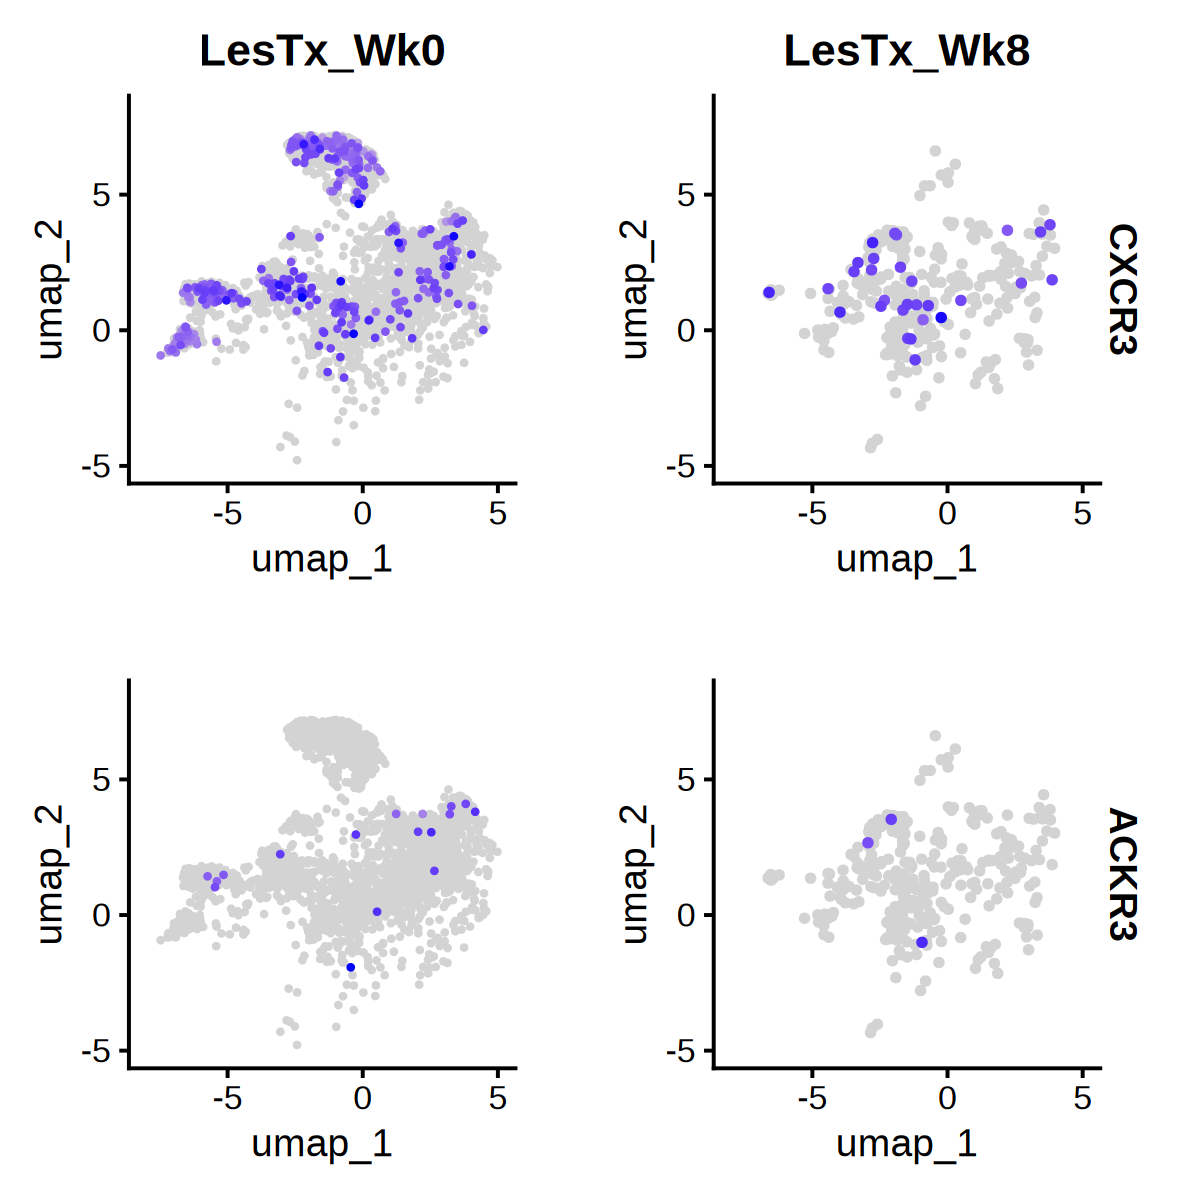

In [71]:
fig.size(6, 6)
FeaturePlot(subset(objT, subset = dataset == 'scRNA-seq'), features = c('CXCR3', 'ACKR3'), 
            order = TRUE, split.by = 'Condition')
# ACKR3 = CXCR7

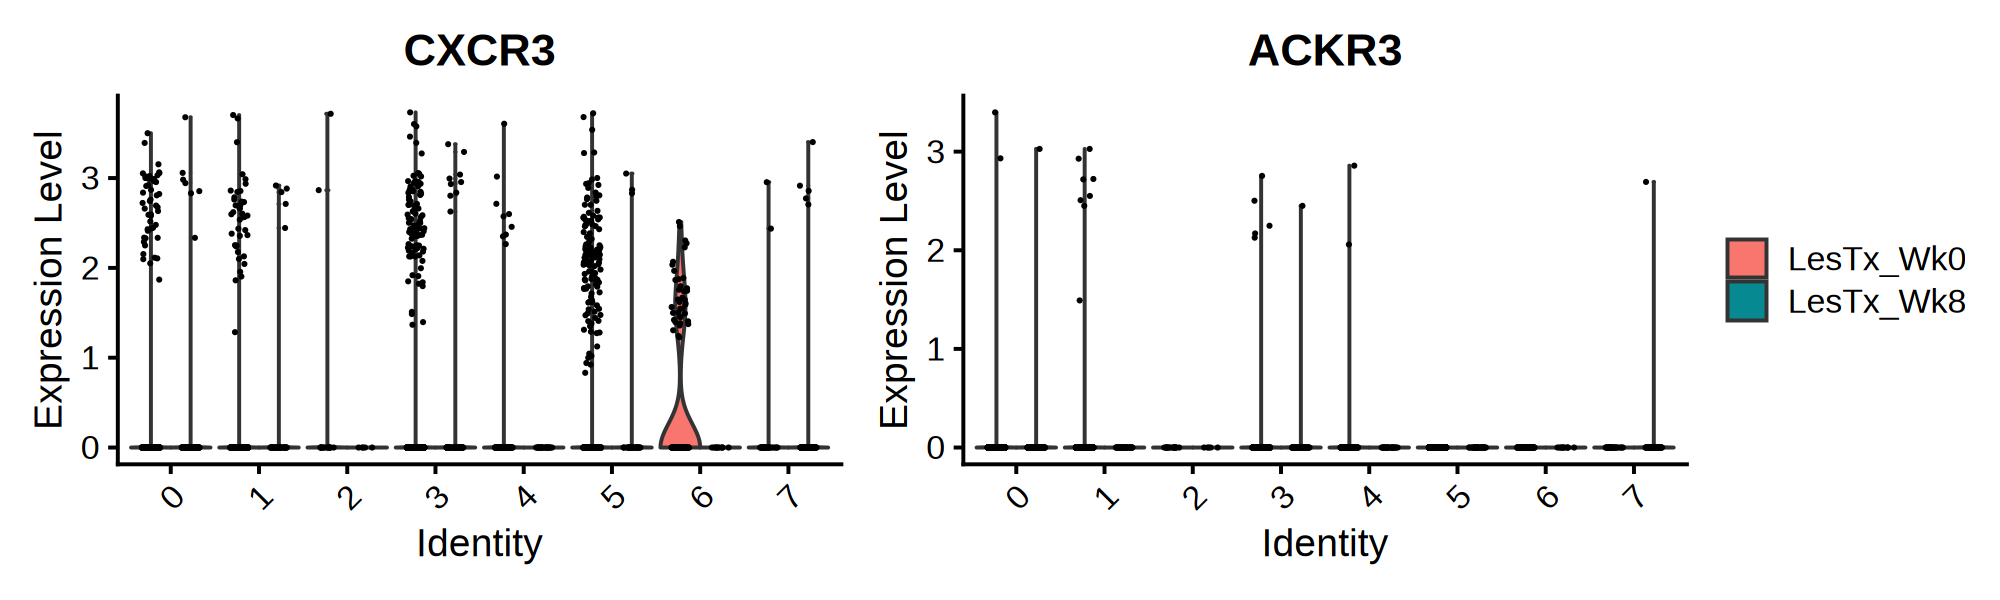

In [77]:
fig.size(3, 10)
VlnPlot(subset(objT, subset = dataset == 'scRNA-seq'), features = c('CXCR3', 'ACKR3'), 
        split.by = 'Condition') + theme(legend.position = 'right')

## DA within T cell subsets

In [41]:
obj_T = readRDS('../data/obj_merged_T.rds')

In [61]:
mydata = cbind(obj_T@meta.data, obj_T@reductions$umap@cell.embeddings) %>%
                mutate(T_cell_type = as.character(RNA_snn_res.0.2))
mydata = mydata %>% filter(dataset == 'scRNA-seq')

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


null device 
          1

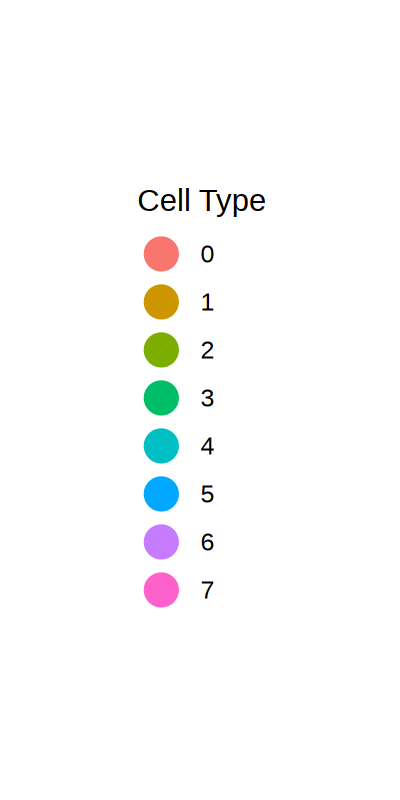

In [62]:
p = mydata %>% ggplot() +
    geom_point_rast(aes(x = umap_1, y = umap_2, col = RNA_snn_res.0.2)) +
    theme_classic() + 
    guides(colour = guide_legend(override.aes = list(size=5))) + 
    labs(col = 'Cell Type')

# Extract the legend. Returns a gtable
leg <- get_legend(p)

fig.size(4, 2)
#pdf('../figures/Fig1_UMAP_merged_legend.pdf', width = 2, height = 4)
# Convert to a ggplot and print
as_ggplot(leg)
dev.off()

In [64]:
# Calculate mean UMAP coordinates for each cell type
label_coords <- mydata %>%
  group_by(RNA_snn_res.0.2) %>%
  summarise(
    mean_UMAP_1 = mean(umap_1),
    mean_UMAP_2 = mean(umap_2)
)

`summarise()` has grouped output by 'Subject_TimePt', 'TimePt'. You can
override using the `.groups` argument.


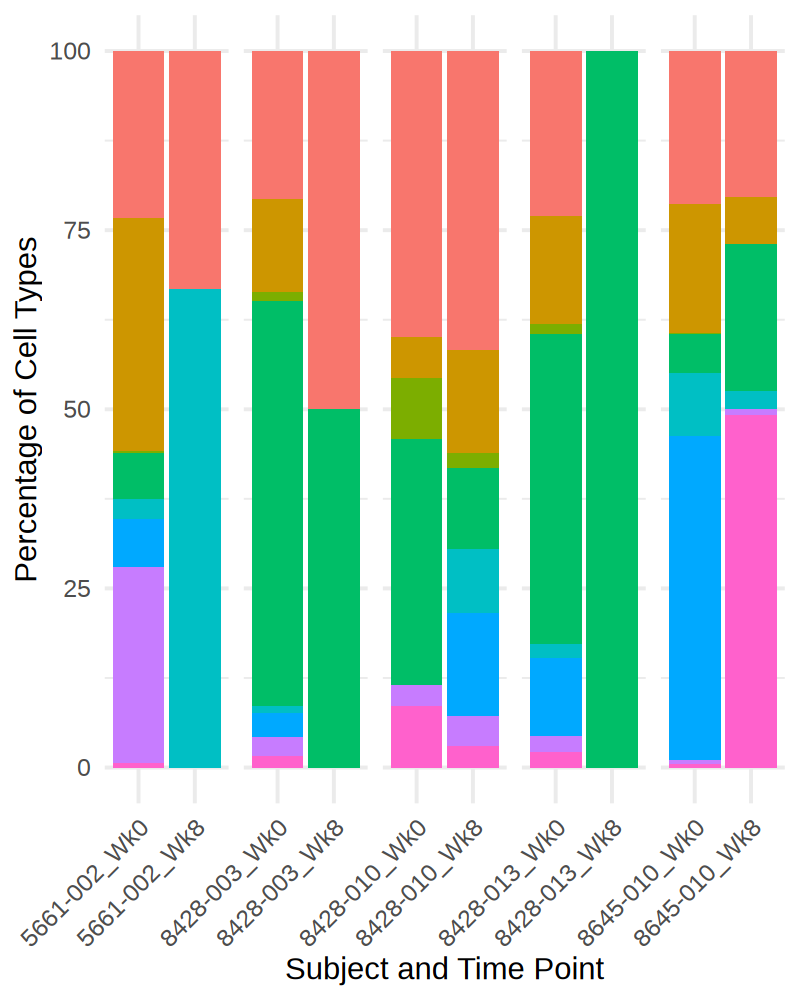

In [65]:
# Create a combined variable for Subject and TimePt
data <- mydata %>% mutate(Subject_TimePt = paste(Subject, TimePt, sep = "_"))

# Summarize the data to get the percentage of each cell type per Subject+TimePt
data_summary1 <- data %>%
  group_by(Subject_TimePt, TimePt, RNA_snn_res.0.2) %>%
  summarise(cell_count = n()) %>%
  mutate(percent = (cell_count / sum(cell_count)) * 100) %>%
  mutate(Pair_Group = gsub("Wk8", "Wk", gsub("Wk0", "Wk", Subject_TimePt))) %>%
  mutate(Pair_Group = paste0('sc', Pair_Group)) %>%
  ungroup()

fig.size(5, 4)
# Create the stacked bar plot
p1 = ggplot(data_summary1, aes(x = Subject_TimePt, y = percent, fill = RNA_snn_res.0.2)) +
  geom_bar(stat = "identity") +
  labs(x = "Subject and Time Point", y = "Percentage of Cell Types") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) + labs(fill = '') +
  facet_grid(. ~ Pair_Group, scales = "free_x", space = "free_x") +
  theme(strip.text.x = element_blank(), legend.position = 'none')

#pdf('../figures/Fig1_Proportions_by_Sample_scRNA.pdf', width = 4, height = 5)
print(p1)
#dev.off()
#p1